# Exam: Text Analysis and Visualization on the Diamonds Dataset

This exam tests your ability to perform text analysis on categorical data from the "diamonds.csv" dataset.
For each question, provide the Python code to perform the requested analysis and generate the visualization.

In [1]:
import pandas as pd
import nltk
from textblob import TextBlob, Word
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re

# Download necessary NLTK data
try:
    nltk.download('punkt')
    nltk.download('stopwords')
    nltk.download('averaged_perceptron_tagger')
    nltk.download('wordnet')
except Exception as e:
    print(f"Error downloading NLTK data: {e}")

# Load the dataset
try:
    import os
    filepath = "./datasets/diamonds.csv"
    if not os.path.exists(filepath):
        filepath = "../datasets/diamonds.csv"

    df = pd.read_csv(filepath)
    print(f"Dataset 'diamonds.csv' loaded successfully from {filepath}.")
except FileNotFoundError:
    print("Error: The dataset file was not found. Please ensure 'diamonds.csv' is in the 'datasets' directory.")
except Exception as e:
    print(f"An error occurred: {e}")


Dataset 'diamonds.csv' loaded successfully from ../datasets/diamonds.csv.


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\bapt7\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bapt7\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\bapt7\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\bapt7\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Question 1: Simulated Sentiment Analysis and Distribution
1.  We will simulate a sentiment analysis on the 'cut' quality. Classify 'Ideal' and 'Premium' as 'positive', 'Good' and 'Very Good' as 'neutral', and 'Fair' as 'negative'. Then, generate a bar chart to visualize this distribution.

C:\Users\bapt7\AppData\Local\Temp\ipykernel_16940\260943231.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=['green', 'blue', 'red'])


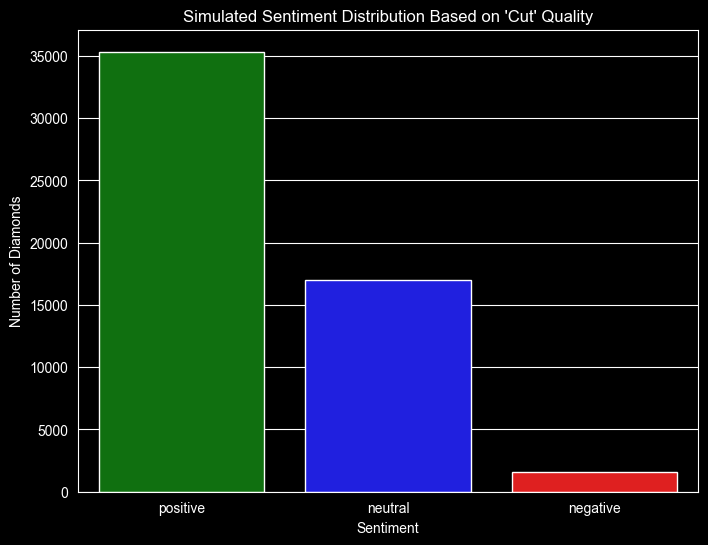

In [2]:
# Answer 1:
if 'df' in locals():
    def assign_sentiment(cut_quality):
        if cut_quality in ['Ideal', 'Premium']:
            return 'positive'
        elif cut_quality in ['Good', 'Very Good']:
            return 'neutral'
        else: # Fair
            return 'negative'

    df['sentiment'] = df['cut'].apply(assign_sentiment)
    sentiment_counts = df['sentiment'].value_counts()

    plt.figure(figsize=(8, 6))
    sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=['green', 'blue', 'red'])
    plt.title("Simulated Sentiment Distribution Based on 'Cut' Quality")
    plt.xlabel('Sentiment')
    plt.ylabel('Number of Diamonds')
    plt.show()


## Question 2: Text Corpus Creation
2.  Create a single text corpus by combining all the values from the 'cut', 'color', and 'clarity' columns. This will serve as our text data for the next steps.

In [3]:
# Answer 2:
if 'df' in locals():
    # Combine the categorical columns into a single text corpus
    text_corpus = ' '.join(df['cut'].astype(str) + ' ' + df['color'].astype(str) + ' ' + df['clarity'].astype(str))
    print("Text corpus created successfully.")
    print("Sample of corpus:", text_corpus[:200])


Text corpus created successfully.
Sample of corpus: Ideal E SI2 Premium E SI1 Good E VS1 Premium I VS2 Good J SI2 Very Good J VVS2 Very Good I VVS1 Very Good H SI1 Fair E VS2 Very Good H VS1 Good J SI1 Ideal J VS1 Premium F SI1 Ideal J SI2 Premium E SI


## Question 3: Top 15 Most Common Terms
3.  From the combined text corpus, calculate the frequency of each unique term and display a bar graph showing the top 15 most common terms.

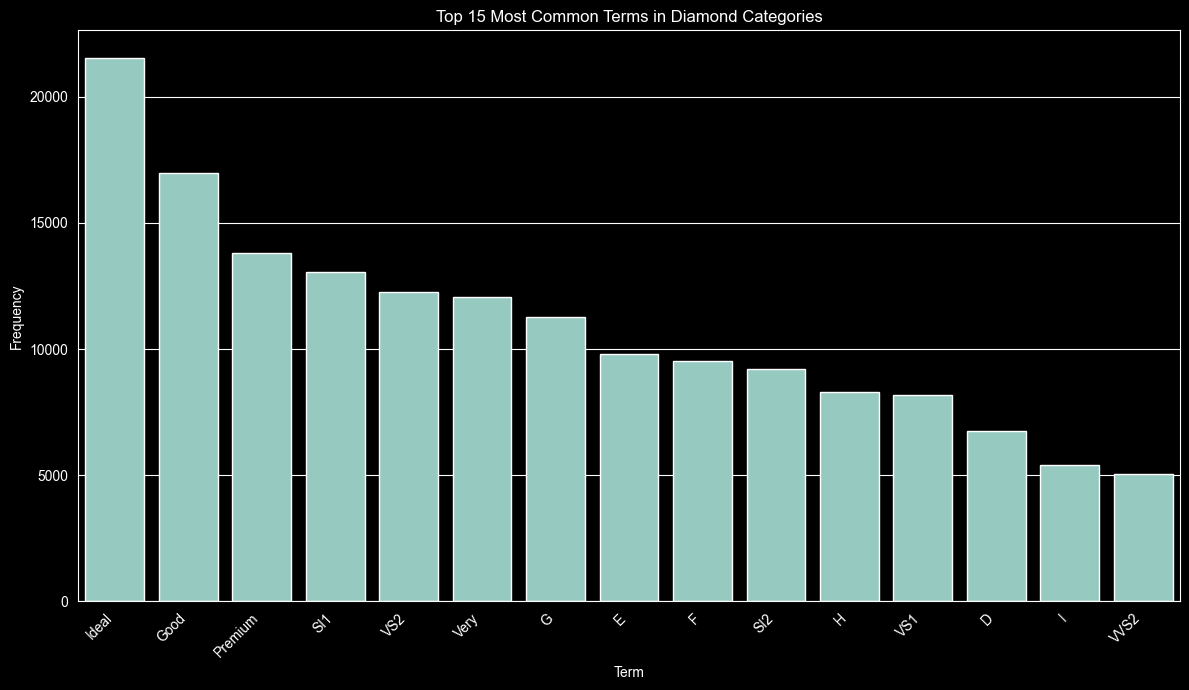

In [4]:
# Answer 3:
if 'text_corpus' in locals():
    words = text_corpus.split()
    word_counts = Counter(words)
    most_common_words = word_counts.most_common(15)

    words, counts = zip(*most_common_words)

    plt.figure(figsize=(12, 7))
    sns.barplot(x=list(words), y=list(counts))
    plt.title('Top 15 Most Common Terms in Diamond Categories')
    plt.xlabel('Term')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## Question 4: Word Cloud
4.  Generate a word cloud from the text corpus to provide a visual summary of the most prominent terms.

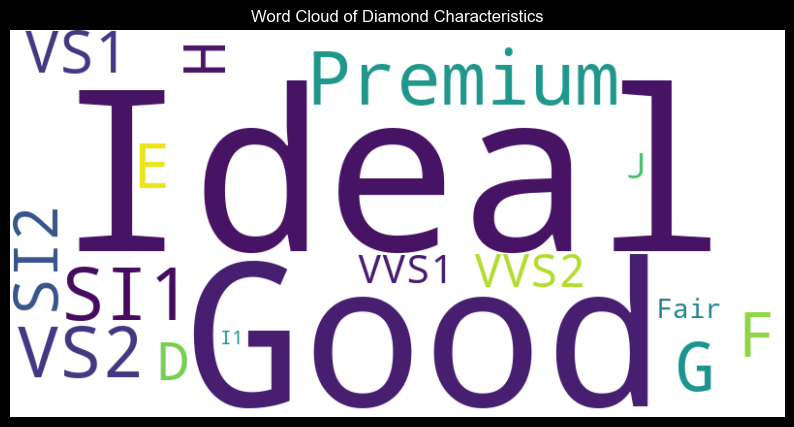

In [5]:
# Answer 4:
if 'text_corpus' in locals():
    wordcloud = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(text_corpus)
    plt.figure(figsize=(10, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Diamond Characteristics')
    plt.show()


## Question 5: Part-of-Speech (POS) Frequency
5.  Visualize the frequency of different Part-of-Speech tags (nouns, adjectives, etc.) in the corpus.

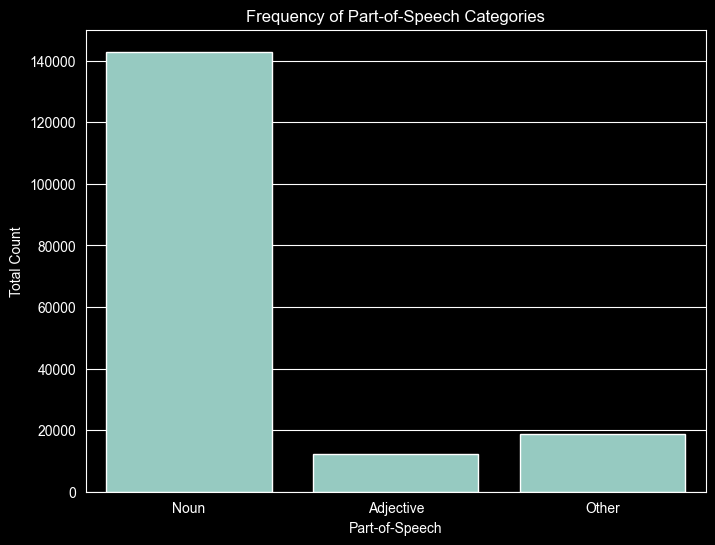

In [6]:
# Answer 5:
if 'text_corpus' in locals():
    blob = TextBlob(text_corpus)
    pos_counts = Counter(tag for word, tag in blob.tags)

    # Focus on major categories
    simple_pos_counts = {'Noun': 0, 'Adjective': 0, 'Other': 0}
    for tag, count in pos_counts.items():
        if tag.startswith('NN'):
            simple_pos_counts['Noun'] += count
        elif tag.startswith('JJ'):
            simple_pos_counts['Adjective'] += count
        else:
            simple_pos_counts['Other'] += count

    plt.figure(figsize=(8, 6))
    sns.barplot(x=list(simple_pos_counts.keys()), y=list(simple_pos_counts.values()))
    plt.title('Frequency of Part-of-Speech Categories')
    plt.xlabel('Part-of-Speech')
    plt.ylabel('Total Count')
    plt.show()
